# Linear Regression of employee salary

## We will predict employee salaries from different employee characteristics (or features). We are going to use a simple supervised learning technique: linear regression. We want to build a simple model to determine how well Years Worked predicts an employee’s salary. A description of the variables is given in Salary Metadata. You will need the packages matplotlib, pandas and statsmodels.

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')

In [3]:
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from statsmodels.tools.eval_measures import rmse
from scipy import stats

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('../data/salary.csv')

In [6]:
df.head()

,salary,exprior,yearsworked,yearsrank,market,degree,otherqual,position,male,Field,yearsabs
0,53000.0,0,0,0,1.17,1,0,1,1,3,0
1,58000.0,1,0,0,1.24,1,0,1,1,2,0
2,45500.0,0,0,0,1.21,1,0,1,1,3,2
3,35782.0,0,2,1,0.99,1,0,1,1,4,1
4,34731.0,0,2,2,0.91,1,0,1,1,4,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 514 entries, 0 to 513
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   salary       513 non-null    float64
 1   exprior      514 non-null    int64  
 2   yearsworked  514 non-null    int64  
 3   yearsrank    514 non-null    int64  
 4   market       514 non-null    float64
 5   degree       514 non-null    int64  
 6   otherqual    514 non-null    int64  
 7   position     514 non-null    int64  
 8   male         514 non-null    int64  
 9   Field        514 non-null    int64  
 10  yearsabs     514 non-null    int64  
dtypes: float64(2), int64(9)
memory usage: 44.3 KB


In [8]:
df.isnull().sum()

salary         1
exprior        0
yearsworked    0
yearsrank      0
market         0
degree         0
otherqual      0
position       0
male           0
Field          0
yearsabs       0
dtype: int64

We found a missing value in the  dataset and replaced the value with the median of the series. The median is the best way we can impute the missing values as it gives us the center of our data.

In [9]:
df['salary'].replace(np.nan, df['salary'].median(), inplace=True)

In [10]:
df[['degree', 'otherqual', 'position','male', 'Field']].astype("category").describe(include='all')

,degree,otherqual,position,male,Field
count,514,514,514,514,514
unique,2,2,3,2,4
top,1,0,3,1,4
freq,496,491,211,386,136


From the above dataframe we can tell that:
- Most have a degree.
- Majority don't have another post-secondary qualification.
- Most people recorded are Executives.
- Majority are males.
- And most work in marketing.


## Salary Metadata

In [11]:
metadata = pd.read_csv('../data/Salary metadata.csv',sep=';')

In [12]:
metadata.head(11)

,Variable,Type,Explanation
0,salary,Continuous,Annual salary in dollars
1,exprior,Continuous,Years of experience prior to working in this f...
2,yearsworked,Continuous,Years worked in this field
3,yearsrank,Continuous,Years worked at current rank
4,market,Continuous,Market value (1 = salary at market value for p...
5,degree,Binary,"Has degree (0 = no, 1 = yes)"
6,otherqual,Binary,Has other post-secondary qualification (0 = no...
7,position,Categorical,"Position (1 = Junior Employee, 2 = Manager, 3 ..."
8,male,Binary,"0 = no, 1 = yes"
9,Field,Categorical,"Field of work (1 = Engineering, 2 = Finance, 3..."


In [13]:
metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Variable     11 non-null     object
 1   Type         11 non-null     object
 2   Explanation  11 non-null     object
dtypes: object(3)
memory usage: 392.0+ bytes


## 1. Split your data into a training and test set. Leave the test set for now. 

### Examine the training data for missing and extreme values. 

- It's not advisable to only look at the training data for missing and extreme values. The reason behind this is because it means that we'd be neglecting to look for missing and extreme values of the X-test as well, there might be outliers within the X-test that we don't know about, that's why it'd be advisable to examine the whole dataframe for these values. Luckily we've already examined our dataframe for null values, which have been replaced with the median of the data. We still need to look for outliers, which will be done below.

### Create histograms to show the distribution of the variables and a scatterplot showing the relationship between Years Worked and Salary. Are the data appropriate for linear regression? Is there anything that needs to be transformed or edited first?

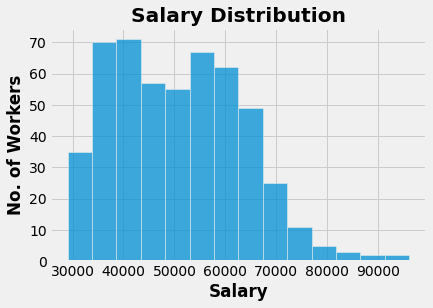

In [14]:
plt.title('Salary Distribution', fontweight='bold')
plt.ylabel('No. of Workers', fontweight='bold')
plt.xlabel('Salary', fontweight='bold')
sns.histplot(df['salary'])
plt.show()

- We can see that majority of employees earn more than 35,000.00 and less than 65,000.00.
- Most people earn 40,000.00.
- The lowest number of income earners is below 10 with salaries between 78,000.00 and around 90,000.00.

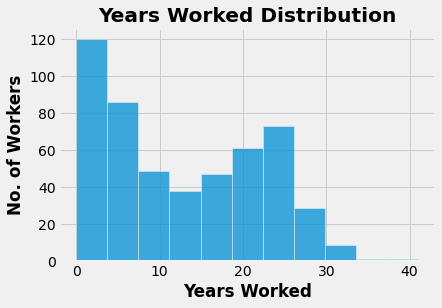

In [15]:
plt.title('Years Worked Distribution', fontweight='bold')
sns.histplot(df['yearsworked'])
plt.ylabel('No. of Workers', fontweight='bold')
plt.xlabel('Years Worked', fontweight='bold')
plt.show()

- A very large number of people work for five years, which is understandable that people start with a high morale when it comes to working.
- As the number of years working increases, the number of employees decreases to a low of less than 40 employees for around 10-15 years worked.
- It's rare to find people working for over 30 years, with a result of about less than 10 employees.

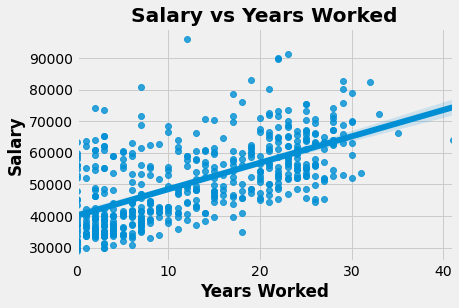

In [16]:
sns.regplot(data=df, x="yearsworked", y='salary')
plt.title('Salary vs Years Worked', fontweight='bold')
plt.ylabel('Salary',fontweight='bold')
plt.xlabel('Years Worked',fontweight='bold')
plt.show()

- We observe a positive correlation between the two variables. When the years worked increases there's a tendency of increasing behaviour within the salary variable

Removing outliers using IQR:

In [17]:
Q1 = df[['yearsworked', 'salary']].quantile(0.25)
Q3 = df[['yearsworked', 'salary']].quantile(0.75)
salary_years_worked_IQR = Q3 - Q1
salary_years_worked_IQR

yearsworked       18.00
salary         20306.25
dtype: float64

In [18]:
Q3

yearsworked       22.00
salary         60306.25
Name: 0.75, dtype: float64

In [19]:
print((df[['yearsworked', 'salary']] < (Q1 - 1.5 * salary_years_worked_IQR)) | (df[['yearsworked', 'salary']] > (Q3 + 1.5 * salary_years_worked_IQR)))

     yearsworked  salary
0          False   False
1          False   False
2          False   False
3          False   False
4          False   False
..           ...     ...
509        False   False
510        False   False
511        False   False
512        False   False
513        False   False

[514 rows x 2 columns]


Remove outliers:

In [20]:
before_outliers = df.shape[0]

In [21]:
df = df[~((df[['yearsworked', 'salary']] < (Q1 - 1.5 * salary_years_worked_IQR)) | (df[['yearsworked', 'salary']] > (Q3 + 1.5 * salary_years_worked_IQR))).any(axis=1)]

In [22]:
assert df.shape[0] != 514, 'No outliers have been removed'

In [23]:
after_outliers = df.shape[0]
print(f'before outliers: {before_outliers} \nafter outliers: {after_outliers}')

before outliers: 514 
after outliers: 512


The original number of rows of the column was 514 but by removing outliers using IQR we managed to remove two records, making it 512. We are now able to split our dataframe into training and test split:

In [24]:
X = df['yearsworked']
y = df['salary']

In [25]:
X = sm.add_constant(X)

We need to provide a constant to assist in providing an accurate view of the slope values, without a constant we're forcing the y-intercerpt through the origin and that may not be an actual representation of the patterns present in the dataset. 

The constant prevents bias by forcing the residual mean to 0. When a constant isn't included, it's required that the dependant and independant variable equal 0 simultaneously otherwise the model will be biased.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

The random state ensures we get the same sequence of random numbers for our dataset, when a fixed integer is given.

## 2. Using the statsmodels package and the training data, run a simple linear regression for Salary with one predictor variable: Years Worked.


In [27]:
model = sm.OLS(y_train, X_train)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 salary   R-squared:                       0.406
Model:                            OLS   Adj. R-squared:                  0.404
Method:                 Least Squares   F-statistic:                     242.9
Date:                Wed, 28 Jul 2021   Prob (F-statistic):           4.12e-42
Time:                        09:36:31   Log-Likelihood:                -3793.0
No. Observations:                 358   AIC:                             7590.
Df Residuals:                     356   BIC:                             7598.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        4.031e+04    845.825     47.653      0.000    3.86e+04     4.2e+04
yearsworked   828.6631     53.175     15.584      0.000     724.087     933.239
==============================================================================
Omnibus:                       43.784   Durbin-Watson:                   2.005
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               56.220
Skew:                           0.936   Prob(JB):                     6.19e-13
Kurtosis:                       3.512   Cond. No.                         26.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [28]:
predictions = results.predict(X_test)

Text(0.5, 1.0, 'Y-test vs Predicted Y')

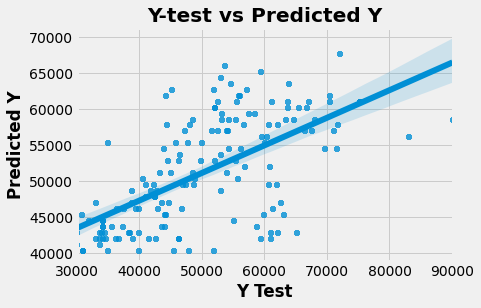

In [29]:
sns.regplot(x = y_test, y = predictions, marker='+')
plt.xlabel('Y Test', fontweight='bold')
plt.ylabel('Predicted Y', fontweight='bold')
plt.title('Y-test vs Predicted Y', fontweight='bold')

- We notice a positive correlation between our y-test and predicted values. Our model works well. It's important to keep in mind that correlation doesn't imply causation.

### Does the model significantly predict the dependent variable? Report the amount of variance explained (R^2) and significance value (p) to support your answer.

R squared allows for an easier interpretation of correlation, by simply looking at our regression line to to find a respective value we can make a good guess about our prediction, to sum it up, R squared is used to quantify the difference in which how much a regression line better fits the data than the mean, and to answer the question, no, a R squared percentage of 40% means most of the variance in the data isn't accounted for by the years worked and salary relationship, about 60% of the variance in the data isn't accounted for. 

If p <= 0.05 there's a significant relationship between the variables, in this case it's 0. Indicating a significant relationship between the variables.

### What percentage of the variance in employees’ salaries is accounted for by the number of years they have worked?

About 40%.

## 3. What does the unstandardized coefficient (B or ‘coef’ in statsmodels) tell you about the relationship between Years Worked and Salary?

Every one unit increase in Years Worked is associated with a Salary of 828.66.

## 4. What do the 95% confidence intervals \[0.025, 0.975\] mean?
["According to Neyman’s CI theory, what a 95% CI actually means is that if we were to draw 100 random samples from the underlying distribution, we would end up with 100 different confidence intervals, and we can be confident that 95 of them will contain the true population parameter within their limits."](https://www.oreilly.com/content/the-trinity-of-errors-in-applying-confidence-intervals-an-exploration-using-statsmodels/#:~:text=According%20to%20Neyman's%20CI%20theory,population%20parameter%20within%20their%20limits.)

## 5. Calculate the expected salary for someone with 12 years’ work experience.

In [30]:
results.predict(pd.DataFrame({'const':1.0,'years':[12]}))

0    50249.926965
dtype: float64

## 6. Calculate the expected salary for someone with 80 years’ work experience. Are there any problems with this prediction? If so, what are they?

In [31]:
results.predict(pd.DataFrame({'const':1.0,'years':[80]}))

0    106599.019599
dtype: float64

- The main problem with an amount of $106,599.00 is that the retirement age for people is 65, this skews our data and is unrealistic for an employee at that age.

## 7. We have only looked at the number of years an employee has worked. What other employee characteristics might influence their salary?

Look at the correlation between our variables below:

<AxesSubplot:>

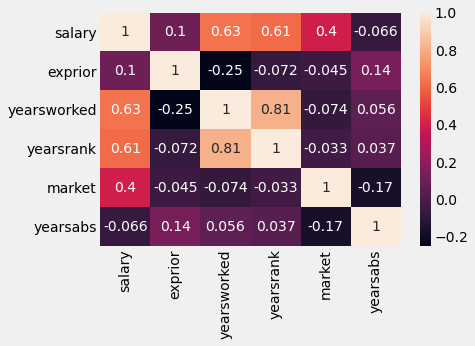

In [32]:
sns.heatmap(df[['salary', 'exprior', 'yearsworked', 'yearsrank', 'market', 'yearsabs']].corr(), annot=True)

From the heatmap above, it's evident that after yearsworked, market and yearsrank have the highest correlation with salary, yearsrank being the second highest. Lets look at the p-value of the variable:

In [33]:
corr_data = {
    'Correlation': [stats.pearsonr(df['salary'], df['exprior'])[0], 
    stats.pearsonr(df['salary'], df['yearsrank'])[0],
    stats.pearsonr(df['salary'], df['market'])[0],
    stats.pearsonr(df['salary'], df['yearsabs'])[0]],

    'P-Value': [stats.pearsonr(df['salary'], df['exprior'])[1],
    stats.pearsonr(df['salary'], df['yearsrank'])[1],
    stats.pearsonr(df['salary'], df['market'])[1],
    stats.pearsonr(df['salary'], df['yearsabs'])[1]]}


df_correlation = pd.DataFrame(data=corr_data, index=['exprior', 'yearsrank', 'market', 'yearsabs'])

In [34]:
df_correlation

,Correlation,P-Value
exprior,0.102544,2.029963e-02
yearsrank,0.613354,3.124960e-54
market,0.397166,8.573780e-21
yearsabs,-0.066453,1.331884e-01


- By looking at the variables above it's evident that 'yearsrank' has the highest chance of influencing salary. Our correlation coefficient of 0.6 indicates a positive relationship between years ranked and employee salary, when squared it's 0.3 therefor we have a slight correlation. The p value is less than 0.05, indicating a significant relationship, thus we reject the null hypothesis which states that there's no relationship between yearsrank and employee salary.

### Now fit your model to your test set. DO NOT BUILD A NEW MODEL ON THE TEST SET! Simply use your existing, model, to predict salaries in the test set.

## 8. How does your model compare when running it on the test set - what is the difference in the Root Mean Square Error (RMSE) between the training and test sets? Is there any evidence of overfitting?

- The most favored metric to evaluate a linear model is Root mean squared error (RMSE), it compares two lists as parameters, one being our predicted values and the other being the true values.


In [35]:
x_train_predictions = results.predict(X_train)
train_rmse = rmse(x_train_predictions, y_train, axis=0)
train_rmse

9663.037013579285

In [36]:
test_rmse = rmse(predictions, y_test, axis=0)
test_rmse

9484.303252321259

In [37]:
model_rmse = test_rmse - train_rmse
percent_diff = round(abs(model_rmse/test_rmse*100),1)

print(f'RMSE error: {model_rmse} \nPercentage Difference: {percent_diff}%')

RMSE error: -178.7337612580268 
Percentage Difference: 1.9%


There's a minor percent difference of 1.9% of the RMSE. To classify the model as overfitting would be far from correct when the RMSE indicates just a small fraction of -178.73. 